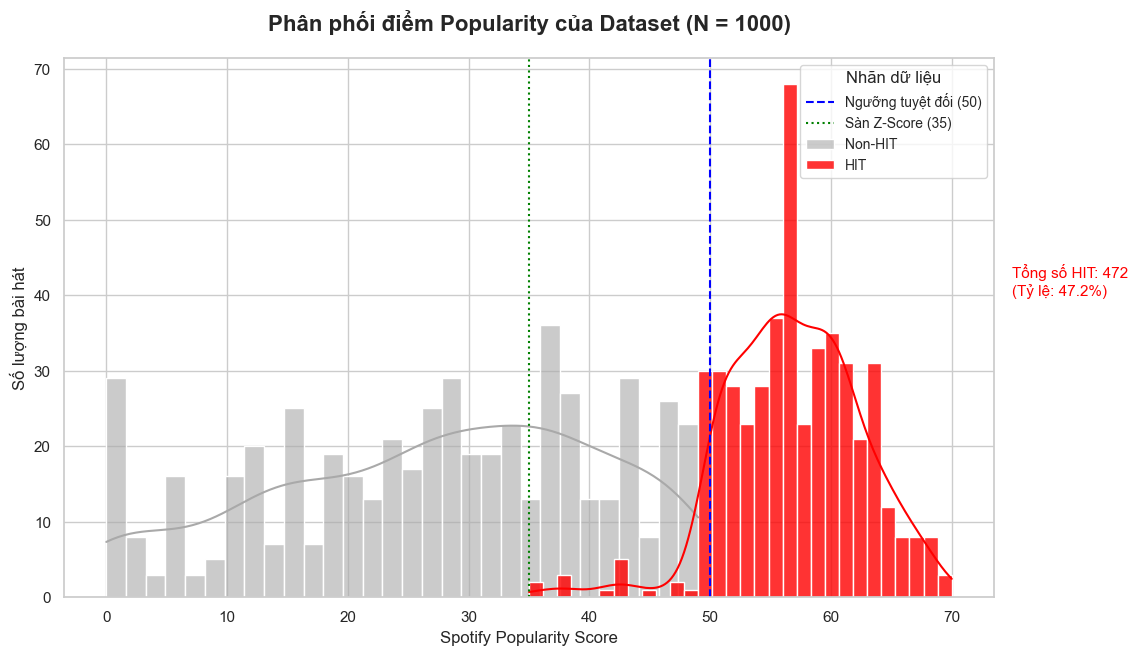

✅ Đã lưu biểu đồ tại: final_data\hit_distribution_chart.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Cấu hình đường dẫn
FILE_PATH = os.path.join( "final_data", "FINAL_DATASET_TRAIN_SCIENTIFIC.csv")

def draw_hit_distribution(file_path):
    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file: {file_path}")
        return

    # 2. Đọc dữ liệu
    df = pd.read_csv(file_path)
    
    # 3. Thiết lập phong cách biểu đồ
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))
    
    # 4. Vẽ Histogram cho 2 nhóm
    # Nhóm Non-Hit (is_hit = 0) - Màu xám
    sns.histplot(data=df[df['is_hit'] == 0], x='spotify_popularity', 
                 color='darkgray', label='Non-HIT', kde=True, bins=30, alpha=0.6)
    
    # Nhóm Hit (is_hit = 1) - Màu đỏ
    sns.histplot(data=df[df['is_hit'] == 1], x='spotify_popularity', 
                 color='red', label='HIT', kde=True, bins=30, alpha=0.8)

    # 5. Vẽ các đường giới hạn định nghĩa (Annotation)
    plt.axvline(x=50, color='blue', linestyle='--', linewidth=1.5, label='Ngưỡng tuyệt đối (50)')
    plt.axvline(x=35, color='green', linestyle=':', linewidth=1.5, label='Sàn Z-Score (35)')

    # 6. Trang trí biểu đồ
    plt.title('Phân phối điểm Popularity của Dataset (N = 1000)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Spotify Popularity Score', fontsize=12)
    plt.ylabel('Số lượng bài hát', fontsize=12)
    plt.legend(title="Nhãn dữ liệu", fontsize=10)
    
    # Thêm chú thích thống kê
    total_hits = df['is_hit'].sum()
    plt.text(75, 40, f'Tổng số HIT: {total_hits}\n(Tỷ lệ: {total_hits/len(df)*100:.1f}%)', 
             bbox=dict(facecolor='white', alpha=0.5), fontsize=11, color='red')

    # 7. Lưu và hiển thị
    output_img = os.path.join("final_data", "hit_distribution_chart.png")
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Đã lưu biểu đồ tại: {output_img}")

if __name__ == "__main__":
    draw_hit_distribution(FILE_PATH)